ADCP data analysis

In [1]:
from mhkit import dolfyn
import matplotlib.pyplot as plt


In [2]:
# loading processed data
ds = dolfyn.load('A0524000_processed.nc')
ds

<xarray.Dataset> Size: 24MB
Dimensions:              (time: 16672, dir: 4, range: 24, beam: 4, x1: 4,
                          x2: 4, earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 133kB 2024-05-15T12:00:00 ... ...
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * range                (range) float32 96B 3.52 4.52 5.52 ... 25.52 26.52
  * beam                 (beam) int32 16B 1 2 3 4
  * x1                   (x1) int64 32B 1 2 3 4
  * x2                   (x2) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/23)
    number               (time) uint32 67kB 193 194 195 ... 16862 16863 16864
    builtin_test_fail    (time) bool 17kB False False False ... False False
    c_sound              (time) float32 67kB 1.507e+03 1.507e+03 ... 1.518e+03
    depth                (time) float32 67kB 22.36 22.36 22.26 ... 23.56 23.66
    pitch                (time) float32 67kB -6.44 -6.44 -6.45 ... -6.7 -6.68
    roll                 (time) float32 67kB -1.2 -1.22 -1.22 ... -1.28 -1.28
    ...                   ...
    corr                 (beam, range, time) uint8 2MB 123 124 123 ... 104 105
    prcnt_gd             (beam, range, time) uint8 2MB 0 0 0 0 0 0 ... 0 0 0 0 0
    beam2inst_orientmat  (x1, x2) float32 64B 1.462 -1.462 0.0 ... -1.034 -1.034
    orientmat            (earth, inst, time) float32 600kB 0.3584 ... -0.993
    vel_filt             (dir, range, time) float32 6MB nan nan nan ... nan nan
    temp_filt            (time) float32 67kB 15.03 15.01 14.99 ... 18.61 18.61
Attributes: (12/40)
    firmware_ver:              50.4
    inst_make:                 TRDI
    inst_type:                 ADCP
    rotate_vars:               ['vel']
    has_imu:                   0
    inst_model:                Workhorse
    ...                        ...
    power_level:               255
    serialnum:                 21788
    range_offset:              1.4
    fs:                        0.0011363636363636363
    declination:               -0.9
    declination_in_orientmat:  1

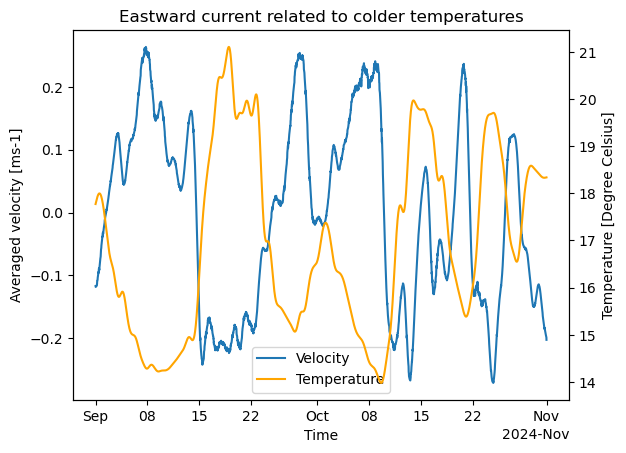

In [16]:
ds['vel_avg'] = ds['vel_filt'].mean(dim='range')

fig, ax1 = plt.subplots()
# Select time range
time_slice = slice('2024-09', '2024-10')

# Plot vel_avg on the left axis
ds['vel_avg'][0].sel(time=time_slice).plot(ax=ax1, label='Velocity')
ax1.set_ylabel('Averaged velocity [ms-1]')
ax1.set_title('Eastward current related to colder temperatures')

# Create a twin axis for temp_filt
ax2 = ax1.twinx()
ds['temp_filt'].sel(time=time_slice).plot(ax=ax2, color='orange', label='Temperature')
ax2.set_ylabel('Temperature [Degree Celsius]')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()